# Homework 2: Exploratory Data Analysis 
## Part 2: Data Analysis
#### Abdullah Junejo (07154)
###### aj07154@st.habib.edu.pk

### Initialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
%matplotlib inline
DF = pd.read_csv('loan_small_Cleaned.csv')
DF

,Id,Member_id,Loan_amnt,Funded_amnt,Funded_amnt_inv,Term_(Months),Int_rate,Installment,Grade,Sub_grade,...,Total_pymnt_inv,Total_rec_prncp,Total_rec_int,Total_rec_late_fee,Recoveries,Collection_recovery_fee,Last_pymnt_d,Last_pymnt_amnt,Last_credit_pull_d,Application_type
0,1077430,1314167,2500,2500,2500.00000,60,15.27,59.83,C,C4,...,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,Sep-13,INDIVIDUAL
1,1076863,1277178,10000,10000,10000.00000,36,13.49,339.31,C,C1,...,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,Jan-15,INDIVIDUAL
2,1075358,1311748,3000,3000,3000.00000,60,12.69,67.79,B,B5,...,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Jan-16,INDIVIDUAL
3,1075269,1311441,5000,5000,5000.00000,36,7.90,156.46,A,A4,...,5631.38,5000.00,631.38,0.00,0.00,0.00,Jan-15,161.03,Sep-15,INDIVIDUAL
4,1069639,1304742,7000,7000,7000.00000,60,15.96,170.08,C,C5,...,8136.84,5110.85,3025.99,0.00,0.00,0.00,Jan-16,170.08,Jan-16,INDIVIDUAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
942,1057818,1289186,7000,7000,7000.00000,36,8.90,222.28,A,A5,...,8000.34,7000.00,1000.34,0.00,0.00,0.00,Dec-14,229.64,Dec-14,INDIVIDUAL
943,1057629,1289394,2425,2425,2425.00000,36,15.27,84.39,C,C4,...,3052.79,2424.99,612.80,15.00,0.00,0.00,Jan-15,16.06,Jul-15,INDIVIDUAL
944,1057621,1289385,6950,6950,6950.00000,36,9.91,223.97,B,B1,...,7349.48,6950.01,399.47,0.00,0.00,0.00,Sep-12,1560.92,Apr-14,INDIVIDUAL
945,1057787,1289153,12375,12375,12344.46478,36,9.91,398.79,B,B1,...,13399.63,12375.01,1058.95,0.00,0.00,0.00,Dec-12,9056.48,Jan-16,INDIVIDUAL


## Table Analysis

#### Loan Amount Analysis

In [3]:
#Generates a grouped summary of loan amount with respect to loan status
DF.groupby('Loan_status')['Loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_status,,,,,,,,
False,169.0,13247.633136,7419.060898,1200.0,8000.0,12000.0,17200.00,35000.0
True,778.0,12802.859897,7465.654242,1000.0,7200.0,11662.5,16343.75,35000.0


##### We See the frequency of True is much higher than False. This means most people have 'good' loan status and little difference in mean amount suggests that abbility to pay off the loans or be on the track to pay off is independent of the loan amount. We see exactly same maximum amount and closely related minimum amount, quartiles, median. This suggests that amount in no way has a huge impact in tendency to have a 'bad' potential loan status. It does play a role but it is not that major I would say. Moreover, The data is distributed with almost the same spread/variance/Standard Deviation.

#### Interest Rate Analysis

In [4]:
#Generates a grouped summary of interest rate with respect to loan status
DF.groupby('Loan_status')['Int_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_status,,,,,,,,
False,169.0,14.421420,3.789518,6.62,11.71,14.27,17.27,23.13
True,778.0,12.683162,3.842814,6.03,9.91,12.42,15.27,23.91


##### Slightly elevated values of quartiles and medians show us that people with 'bad' loan status are more likely to have higher interest rate packages. The Upper and lower bounds along with standard deviation remain the same probably due to banking policies. This means bank is fair in giving loans and does not have any bias. Mean interest rate is also higher, suggesting its connection with 'Loan Status'.

## Univariate Analysis

Text(0.5, 1.0, 'Loan Status Frequency')

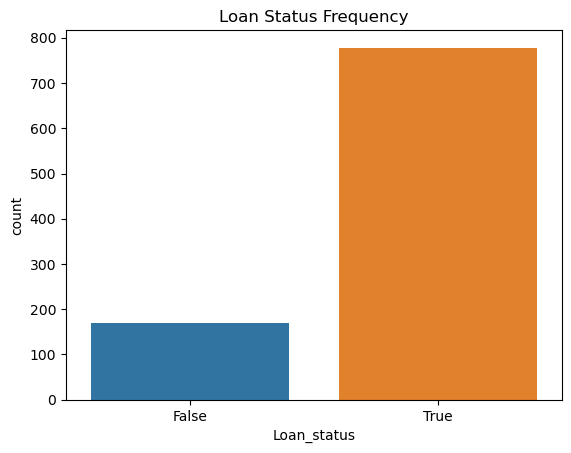

In [5]:
#Bar Chart
sns.countplot(x='Loan_status', data=DF)
plt.title('Loan Status Frequency')

##### We can see that most bank customers are paying having a good status! This means that Bank strategies/loan plans are working effectively. 

Text(0.5, 1.0, 'Borrowers State')

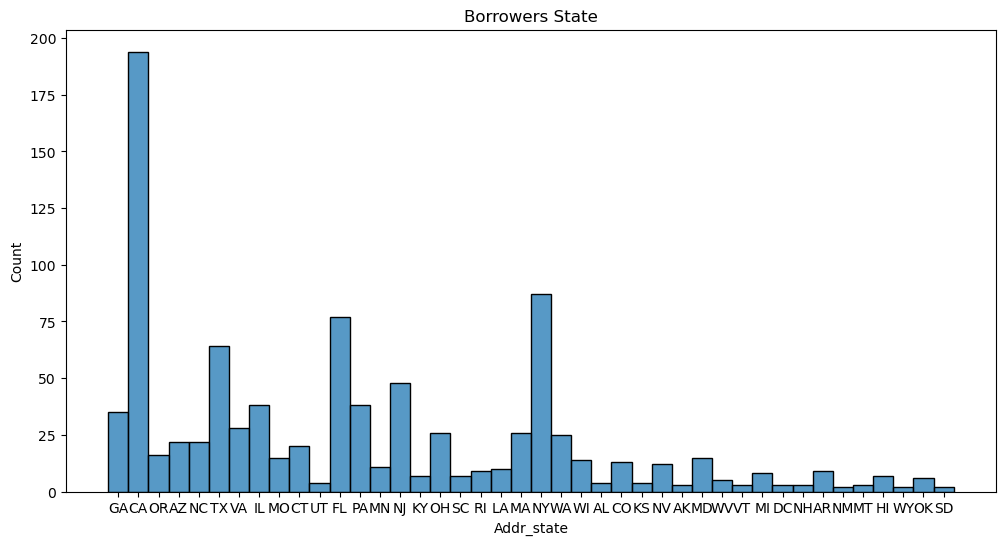

In [12]:
#Histogram
plt.figure(figsize=(12, 6)) #Makes Plot more readable (larger in size)
sns.histplot(DF['Addr_state'], kde=False, bins=10)
plt.title('Borrowers State')

##### The following histogram shows in which state does the borrower belong to. California has very high borrowers compared to others for some reason. This could be due to it being the most populous state. But the second, third, fourth state by population are Texas, Florida, and New York, and they have little difference amongst each other. However, This shows us that California has a huge number of borrowers without much difference in population. This could be due to underlying social reasons that has led the populace to be indebted.

## Visualizations for Bivariate analysis

Text(0.5, 1.0, 'Scatter plot of Loan Amount wrt Annual Income')

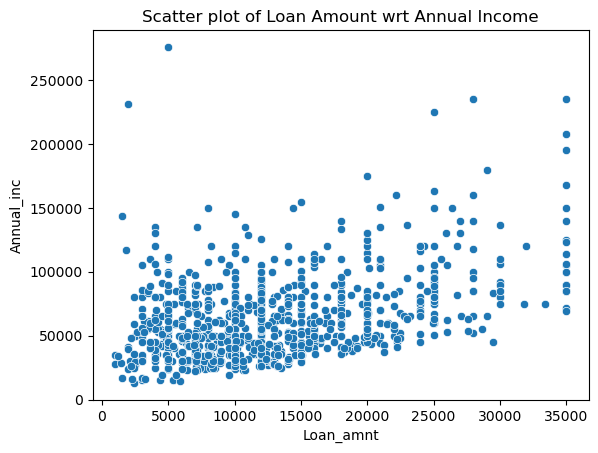

In [9]:
#Scatter plot
sns.scatterplot(x='Loan_amnt', y='Annual_inc', data=DF)
plt.title('Scatter plot of Loan Amount wrt Annual Income')

##### The scatter plot suggests a positive correlation between the loan amount and the annual income. It is natural to think of high earning individuals to go for higher amount loans and vice versa. We can see few exceptions to this assumption, however the correlation generally and overall holds positive. We can also see the cluster at bottom left corner which suggests that most loans are relatively lower in amount and taken by those who have relatively lower annual income.

Text(0.5, 1.0, 'Boxplot of Term Length wrt Interest Rate')

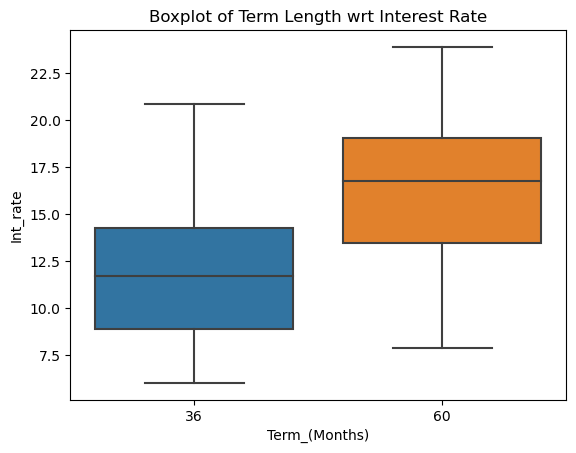

In [19]:
#Discrete vs Continuous (Used Boxplot)

sns.boxplot(x='Term_(Months)', y='Int_rate', data=DF)
plt.title('Boxplot of Term Length wrt Interest Rate')

##### The median interest rate for 36 months is a little less than 12.5% and the median interest rate for 60 months is little less than 17.5%. The length of range is similar and so is Standard deviation from the looks of it. However, Shift in Median and Quartiles tell us a different story. This shows that Loans with bigger Term Length have a higher interest rate as well. This is also a natural assumption as generally bigger loans have a bigger window and therefore a bigger interest rate.

Text(0.5, 1.0, 'Correlation Plot')

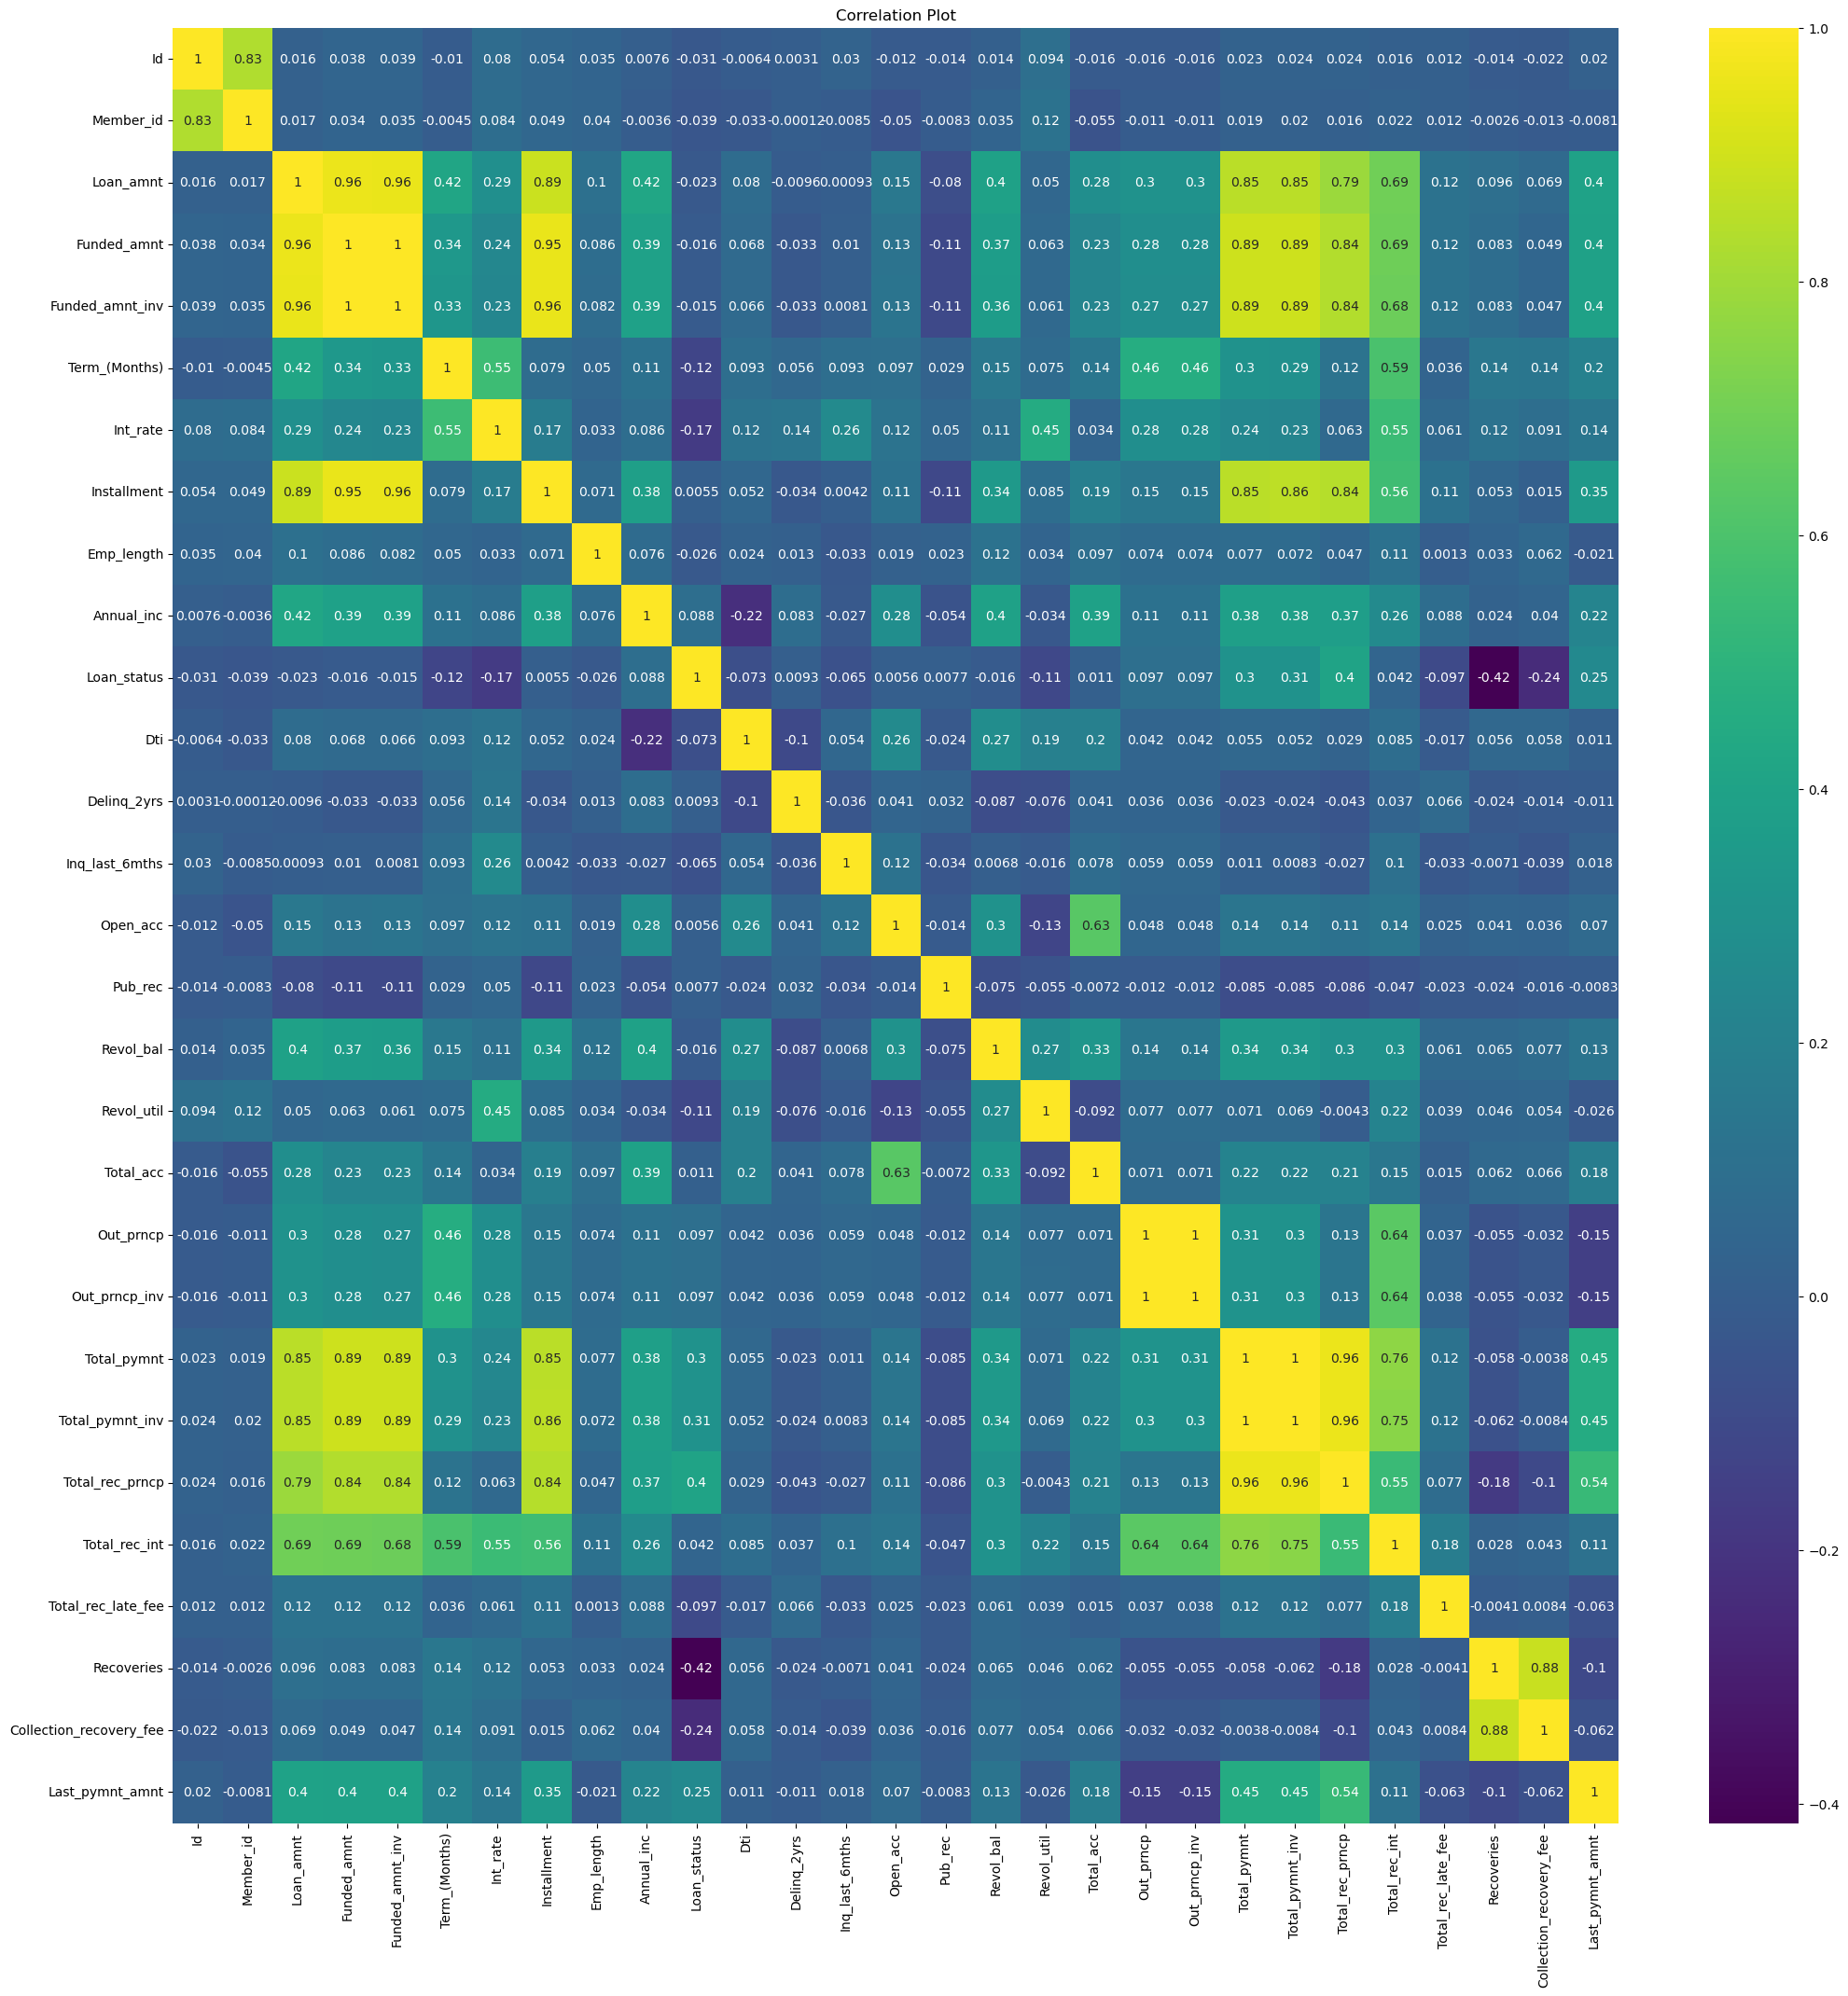

In [31]:
#Correlation plot

plt.figure(figsize = (25,25)) #Increase the size from here if not visible properly during checking.
sns.heatmap(DF.corr(numeric_only=True),cmap='viridis',annot=True)
plt.title('Correlation Plot')

##### Yellowish green/Light Green shows strong corelation. Bright Yellow is the strongest correlation but that is only between a variable and itself. Ignoring that, the pinnacle of correlating can be thought of as green. The lighter the shade the better. Now what does the correlation mean? This means that the block that indicates a corelation,one variable's value increases, the other increases as well. For example, installment and total payment have a positive correlation which is correct since higher the installment would be, more would be the payment. Recoveries and Loan Status can be thought of as farthest from corelation whereas funded amount and loan amount can be thought of as a good pair as their correlation is 0.96.

## Multivariate Analysis

Text(0.5, 1.0, 'Catplot of Grade, Interest Rate and Home Ownership Status')

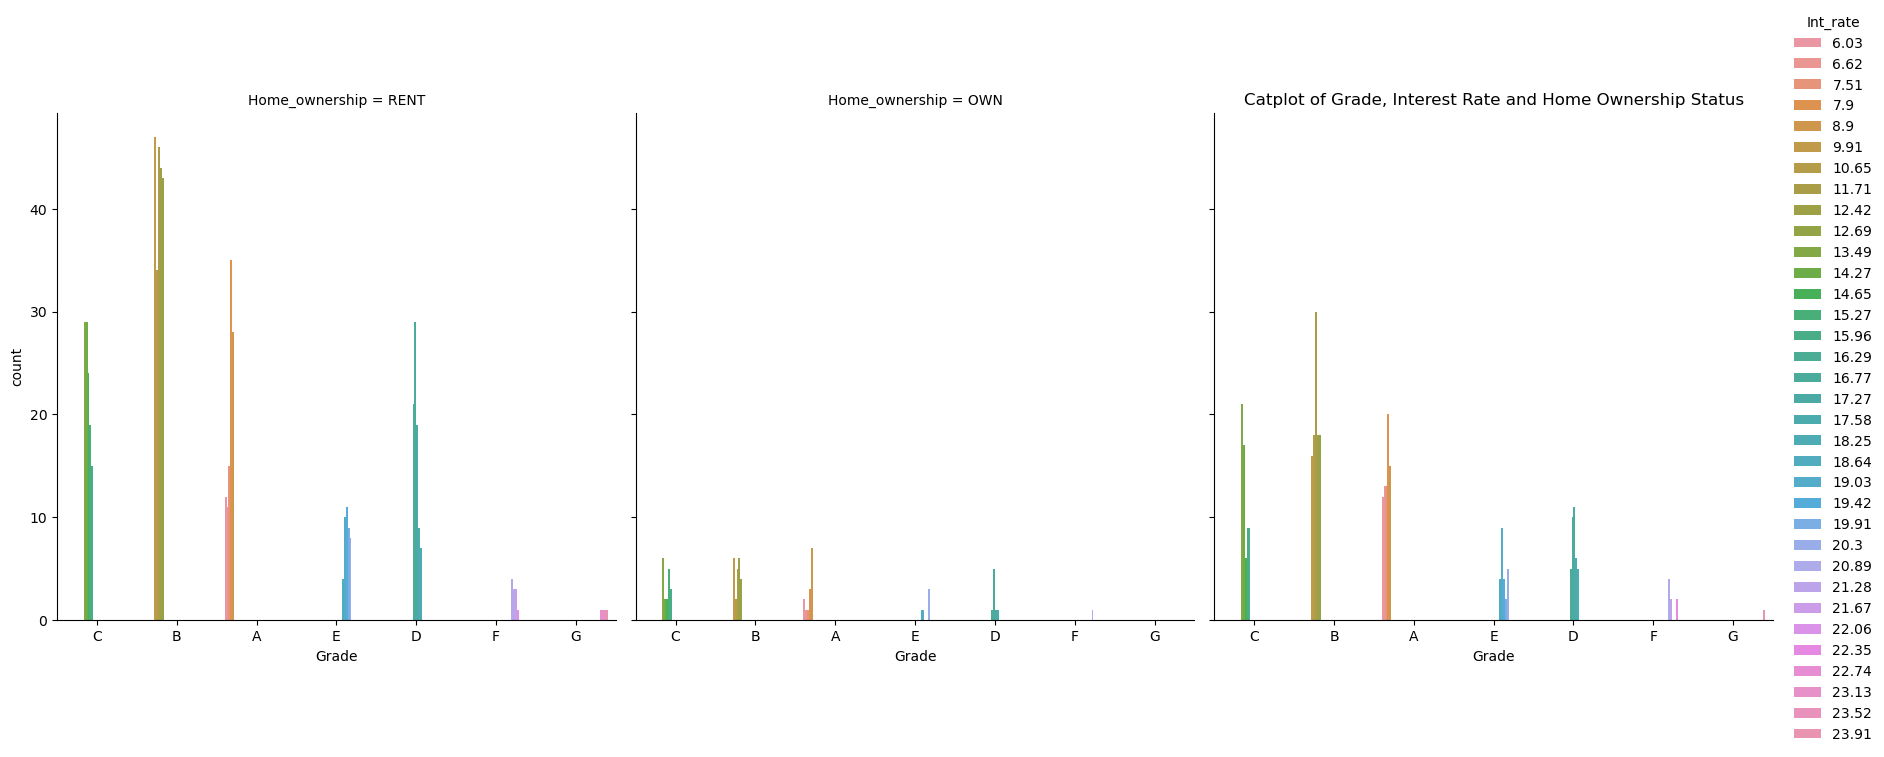

In [55]:
#Multivariate Analysis (Catplot)
sns.catplot(x="Grade", hue="Int_rate", col="Home_ownership",
                data=DF, kind="count",
                height=6, aspect=1);
plt.title('Catplot of Grade, Interest Rate and Home Ownership Status')

##### The cat plot between grade, interest, and Home Ownership demonstratesus that the people having higher grades (A, B, C) have lower interest rates and are usually on Rent, followed by mortgage, followed by Own. Another change that we see is that Grade has very weak correlation with home_ownership status because we more or less see the same distribution. Grade A B C being the highest ones and others being the lowest ones. We can fairly conclude that bank officers do not make the bias of which grade of loan to give based on house ownership status.

## The End